In [278]:
import matplotlib.pyplot as plt
import numpy as np
from metrics import fsc, fouriercorr_plot
from scipy.ndimage import gaussian_filter

#### Generate the volumes

Here we generate:
- a first volume with random numbers
- a second volume by adding gaussian noise to the first

In [279]:
# Add gaussian noise to the image
def add_gaussian_noise(volume, mean=0.0, std=0.1):
    noise = np.random.normal(mean, std, volume.shape)
    return volume + noise

original_vol = gaussian_filter(np.random.randn(110,120,100), sigma=3)
noisy_vol = add_gaussian_noise(original_vol, mean=0.0, std=0.03)

#### Visualise the volumes

In [280]:
def plot_vol(noisy_vol, original, title=''):
    
    pshape = noisy_vol.shape[0]

    pos_limit = np.max(original) 
    neg_limit = np.min(original)
    
    fig, axes = plt.subplots(ncols=3, nrows=2, figsize=(6,4), dpi=100)
    for i in range(3):
        for j in range(2):
            ax = axes[j,i]
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xticklabels([])
            ax.set_yticklabels([])
    axes[0,0].set_title("slice(Z)")
    axes[0,1].set_title("slice(Y)")
    axes[0,2].set_title("slice(X)")
    axes[0,0].set_ylabel("Original vol")
    axes[0,0].imshow(original[pshape//2], vmin=neg_limit, vmax=pos_limit)
    axes[0,1].imshow(original[:,pshape//2], vmin=neg_limit, vmax=pos_limit)
    axes[0,2].imshow(original[:,:,pshape//2], vmin=neg_limit, vmax=pos_limit)
    axes[1,0].set_ylabel("Noisy vol")
    axes[1,0].imshow(noisy_vol[pshape//2], vmin=neg_limit, vmax=pos_limit)
    axes[1,1].imshow(noisy_vol[:,pshape//2], vmin=neg_limit, vmax=pos_limit)
    im1 = axes[1,2].imshow(noisy_vol[:,:,pshape//2], vmin=neg_limit, vmax=pos_limit)
    fig.suptitle('Volumes')
    fig.colorbar(im1, ax=axes.ravel().tolist())


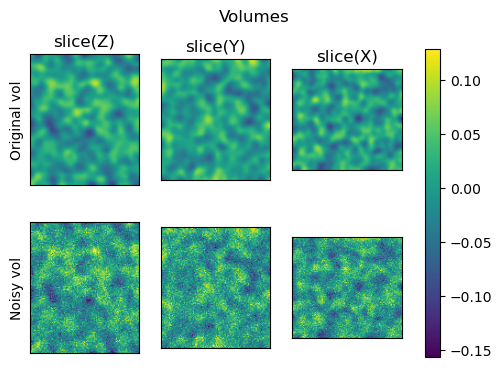

In [281]:
plot_vol(noisy_vol, original_vol)

#### Compute the FSC and plot

The amount of noise added to generate volume 2 was relatively small, and this is reflected in the FSC curve.

/home/kpv14943/ptypy/ptypy/utils/metrics.py:130: UserWarning: For now, the alignment of 3D images has not been implemented yet!
  warnings.warn("For now, the alignment of 3D images has not been implemented yet!")


Apodization in 3D. This takes time and memory...
Computing FRC using 1-bit threshold
Calculating the correlation...


Done


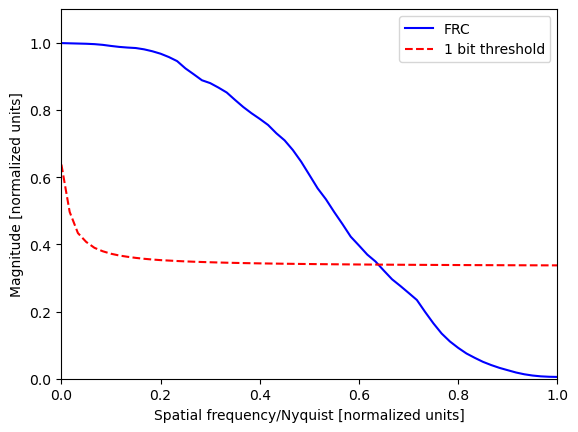

In [282]:
FSC, T, fn = fsc(
    noisy_vol, 
    original_vol, 
    apod_width = 100, 
    ringthick=2, 
    threshold ='onebit',
    apod_type='transverse'
)
fouriercorr_plot(FSC, T, fn, 'fsc_test1_on_random_volumes.png')


#### Increasing noise in the second volume

Now we generate another volume, still by adding noise to the first volume, but a larger amount of noise. This change has a clear impact on the FSC curve.

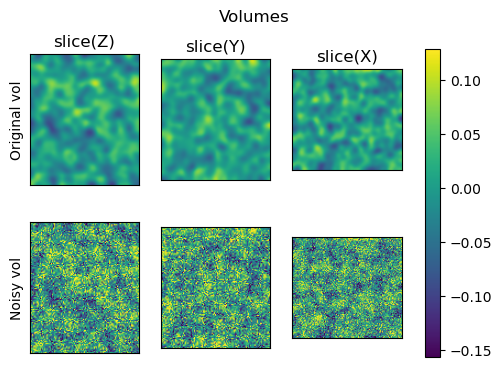

In [283]:
noisy_vol2 = add_gaussian_noise(original_vol, mean=0.0, std=0.07)
plot_vol(noisy_vol2, original_vol)

/home/kpv14943/ptypy/ptypy/utils/metrics.py:130: UserWarning: For now, the alignment of 3D images has not been implemented yet!
  warnings.warn("For now, the alignment of 3D images has not been implemented yet!")


Apodization in 3D. This takes time and memory...
Computing FRC using 1-bit threshold
Calculating the correlation...


Done


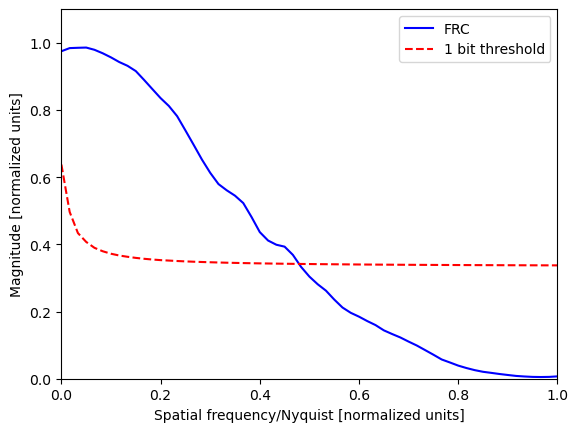

In [284]:
FSC2, T2, fn2 = fsc(
    noisy_vol2, 
    original_vol, 
    apod_width = 100, 
    ringthick=2, 
    threshold ='onebit',
    apod_type='transverse'
)
fouriercorr_plot(FSC2, T2, fn2, 'fsc_test2_on_random_volumes.png')
